In [ ]:
import os
import time
import pandas as pd
import google.generativeai as genai
from PIL import Image

# ===== Step 1: API Configuration =====
GOOGLE_API_KEY = "xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx"  # Replace with your own API key
genai.configure(api_key=GOOGLE_API_KEY)

# Verify if API key is valid
print("🔐 Verifying API key...")
try:
    for m in genai.list_models():
        pass
    print("✅ API key is valid\n")
except Exception as e:
    print(f"❌ API key error: {e}\n")

# List all available models
print("🔍 Checking available models...\n")
available_models = []
for m in genai.list_models():
    if 'generateContent' in m.supported_generation_methods:
        available_models.append(m.name)

# Select the latest model
if 'models/gemini-2.5-flash' in available_models:
    model_name = 'gemini-2.5-flash'
elif available_models:
    model_name = available_models[0]
else:
    model_name = 'gemini-pro'

print(f"✅ Using model: {model_name}\n")
model = genai.GenerativeModel(model_name)

# ===== Step 2: Path Configuration =====
img_folder = r"C:\Users\asus\Desktop\RC11 TERM2\huazuo"
test_count = 5

def get_image_description(image_path):
    """Call Gemini API to generate image descriptions"""
    prompt = """
    Please provide a concise description of this painting in 1-2 sentences.
    Focus on the main subject, activity, and atmosphere.
    Keep it short and factual.
    """
    try:
        img = Image.open(image_path)
        response = model.generate_content([prompt, img])
        return response.text.strip()
    except Exception as e:
        return f"Error: {str(e)[:80]}"

# ===== Step 3: Execute Test =====
print(f"🚀 Starting analysis of first {test_count} images...\n")
image_files = sorted([f for f in os.listdir(img_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
test_files = image_files[:test_count]

results = []

for i, filename in enumerate(test_files, 1):
    path = os.path.join(img_folder, filename)
    print(f"[{i}/{test_count}] Processing: {filename}")
    
    description = get_image_description(path)
    print(f"     Description: {description}\n")
    
    results.append({
        'Image Number': filename,
        'Description': description
    })
    
    time.sleep(1.5)  # Avoid API rate limiting

# ===== Step 4: Save Results =====
print("="*60)
print("✅ Analysis complete! Results below:")
df_result = pd.DataFrame(results)
print(df_result)

# Save to CSV
output_path = r"C:\Users\asus\Desktop\RC11 TERM2\image_descriptions.csv"
try:
    df_result.to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f"\n✅ Results saved to: {output_path}")
except Exception as e:
    print(f"\n⚠️  Save failed: {e}")
    print("   Data saved in memory as df_result variable")

🔐 验证 API 密钥...
✅ API 密钥有效

🔍 检查可用模型...

✅ 使用模型: gemini-2.5-flash

🚀 开始分析前 5 张图片...

[1/5] 正在处理: 000001.jpg
     描述: An artist, viewed from behind, meticulously paints a young woman posing as a muse, adorned with a laurel wreath and holding a trumpet and a book. This quiet, domestic interior scene is partially framed by a heavy curtain, with a large map of the Netherlands prominently displayed on the background wall.

     描述: An artist, viewed from behind, meticulously paints a young woman posing as a muse, adorned with a laurel wreath and holding a trumpet and a book. This quiet, domestic interior scene is partially framed by a heavy curtain, with a large map of the Netherlands prominently displayed on the background wall.

[2/5] 正在处理: 000002.jpg
[2/5] 正在处理: 000002.jpg
     描述: An older man with a somber, reddish face and dark coat stands indoors, gazing directly at the viewer. Behind him, a window reveals a stark, snow-covered winter landscape, contributing to an introspective and so

# Chapter 1: Gemini API Interaction & Painting Analysis

## Overview
This notebook demonstrates how to interact with Google's Gemini API to automatically generate descriptions for a large collection of historical paintings. The workflow includes:

1. **API Configuration & Verification** - Set up the Gemini API with proper authentication
2. **Batch Image Processing** - Process images with retry logic and progress tracking
3. **Error Handling & Logging** - Implement robust error handling with checkpointing
4. **Results Visualization** - Display images alongside their AI-generated descriptions

## Key Features
- **Progress Checkpointing**: Resume processing from where it left off
- **Retry Mechanism**: Exponential backoff for rate limiting
- **Error Logging**: Track failed images for manual review
- **Progress Tracking**: Real-time ETA and processing speed metrics

## Data Flow
```
Image Folder → Gemini API → Description Generated → CSV Output → Visualization
```

---

In [ ]:
# ===== View Final Result Statistics =====
import pandas as pd
import os

output_csv = r"C:\Users\asus\Desktop\RC11 TERM2\all_descriptions.csv"
error_log = r"C:\Users\asus\Desktop\RC11 TERM2\error_log.txt"

# Load results
if os.path.exists(output_csv):
    df = pd.read_csv(output_csv, encoding='utf-8-sig')
    print("="*70)
    print("✅ Analysis Complete! Final Statistics")
    print("="*70)
    print(f"\n📊 Processing Statistics:")
    print(f"   ✅ Successfully analyzed: {len(df)} images")
    print(f"   📁 Target folder: C:\\Users\\asus\\Desktop\\RC11 TERM2\\huazuo")
    print(f"   💾 Result file: {output_csv}\n")
    
    print("📑 Result Preview (Last 10 entries):")
    print("-"*70)
    for idx, row in df.tail(10).iterrows():
        print(f"{idx+1-max(0,len(df)-10):3d}. {row['图片编号']}")
        print(f"     {row['描述']}\n")
    
    # Check error log
    if os.path.exists(error_log):
        with open(error_log, 'r', encoding='utf-8') as f:
            errors = f.readlines()
        if errors:
            print("="*70)
            print(f"⚠️  Failed images ({len(errors)} images):")
            print("-"*70)
            for error in errors[-10:]:  # Show last 10 errors
                print(error.strip())
else:
    print("❌ Result file not found")

✅ 分析完成！最终统计

📊 处理统计:
   ✅ 成功分析: 1101 张图片
   📁 目标文件夹: C:\Users\asus\Desktop\RC11 TERM2\huazuo
   💾 结果文件: C:\Users\asus\Desktop\RC11 TERM2\all_descriptions.csv

📑 结果预览 (最后 10 条):
----------------------------------------------------------------------
  1. 001093.jpg
     This abstract painting features a dense, textured central square of mottled dark grays, whites, and warm ochre, framed by progressively lighter, open grid patterns adorned with scattered paint droplets. The overall composition creates an ethereal, aged atmosphere with a blend of intricate chaos and delicate structure.

  2. 001094.jpg
     This drypoint or etching portrays a woman in a hat, leaning on a surface within a loosely sketched interior. The spontaneous lines create an intimate and casual atmosphere.

  3. 001095.jpg
     This is a framed leaded glass window panel featuring a minimalist geometric design. It combines large clear panes with an intricate vertical column of smaller translucent and clear rectangular a

## Section 1: Quick Test (First 5 Images)

In [ ]:
import os
import time
import json
import pandas as pd
import google.generativeai as genai
from PIL import Image
from datetime import datetime

# ===== Step 1: API Configuration =====
GOOGLE_API_KEY = "xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx"  # Replace with your own API key
genai.configure(api_key=GOOGLE_API_KEY)
model = genai.GenerativeModel('gemini-2.5-flash')

# ===== Step 2: Configuration Parameters =====
img_folder = r"C:\Users\asus\Desktop\RC11 TERM2\huazuo"
output_csv = r"C:\Users\asus\Desktop\RC11 TERM2\all_descriptions.csv"
checkpoint_file = r"C:\Users\asus\Desktop\RC11 TERM2\checkpoint.json"
error_log = r"C:\Users\asus\Desktop\RC11 TERM2\error_log.txt"

MAX_RETRIES = 3  # Number of retries on failure
RETRY_DELAY = 5  # Retry delay (seconds)

# ===== Step 3: Helper Functions =====
def load_checkpoint():
    """Load progress checkpoint"""
    if os.path.exists(checkpoint_file):
        try:
            with open(checkpoint_file, 'r', encoding='utf-8') as f:
                return json.load(f)
        except:
            return {'processed': [], 'failed': []}
    return {'processed': [], 'failed': []}

def save_checkpoint(data):
    """Save progress checkpoint"""
    with open(checkpoint_file, 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

def log_error(filename, error_msg):
    """Log errors"""
    with open(error_log, 'a', encoding='utf-8') as f:
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        f.write(f"[{timestamp}] {filename}: {error_msg}\n")

def get_image_description_with_retry(image_path, max_retries=MAX_RETRIES):
    """Get image descriptions with retry mechanism"""
    prompt = """
    Please provide a concise description of this painting in 1-2 sentences.
    Focus on the main subject, activity, and atmosphere.
    Keep it short and factual.
    """
    
    for attempt in range(max_retries):
        try:
            img = Image.open(image_path)
            response = model.generate_content([prompt, img])
            return response.text.strip(), True
        except Exception as e:
            error_msg = str(e)
            if attempt < max_retries - 1:
                if '429' in error_msg or '403' in error_msg:  # Rate limit or permission error
                    wait_time = RETRY_DELAY * (2 ** attempt)  # Exponential backoff
                    print(f"   ⚠️  Rate limit/permission error, retrying in {wait_time}s...")
                    time.sleep(wait_time)
                else:
                    time.sleep(2)
            else:
                log_error(os.path.basename(image_path), error_msg[:100])
                return f"Error: {error_msg[:80]}", False
    
    return "Error: Max retries exceeded", False

# ===== Step 4: Main Processing Pipeline =====
print("="*70)
print("🚀 Large-Scale Image Analysis System")
print("="*70)
print(f"📁 Image folder: {img_folder}")
print(f"💾 Output CSV: {output_csv}")
print(f"🔖 Checkpoint: {checkpoint_file}\n")

# Get all image files
print("📊 Scanning image files...")
image_files = sorted([f for f in os.listdir(img_folder) 
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
total_images = len(image_files)
print(f"✅ Found {total_images} images\n")

# Load previous progress
checkpoint = load_checkpoint()
processed_files = set(checkpoint['processed'])
failed_files = set(checkpoint['failed'])
remaining_files = [f for f in image_files if f not in processed_files and f not in failed_files]

print(f"📈 Progress Statistics:")
print(f"   ✅ Completed: {len(processed_files)} images")
print(f"   ❌ Failed: {len(failed_files)} images")
print(f"   ⏳ Pending: {len(remaining_files)} images")
print(f"   📊 Total: {total_images} images\n")

# Load existing results
if os.path.exists(output_csv):
    df_results = pd.read_csv(output_csv, encoding='utf-8-sig')
    print(f"📂 Loaded existing results: {len(df_results)} records\n")
else:
    df_results = pd.DataFrame(columns=['Image Number', 'Description'])

# ===== Step 5: Start Processing =====
start_time = datetime.now()
print("🔄 Starting image processing...")
print("-"*70)

results = []
for idx, filename in enumerate(remaining_files, 1):
    image_path = os.path.join(img_folder, filename)
    
    # Display progress
    progress_pct = ((len(processed_files) + idx - 1) / total_images) * 100
    print(f"[{len(processed_files) + idx:4d}/{total_images}] ({progress_pct:5.1f}%) Processing: {filename}")
    
    # Get description
    description, success = get_image_description_with_retry(image_path)
    
    if success:
        print(f"     ✅ Success: {description[:60]}...")
        results.append({'Image Number': filename, 'Description': description})
        checkpoint['processed'].append(filename)
    else:
        print(f"     ❌ Failed")
        checkpoint['failed'].append(filename)
    
    # Periodically save progress
    if idx % 10 == 0:
        save_checkpoint(checkpoint)
        df_temp = pd.concat([df_results, pd.DataFrame(results)], ignore_index=True)
        df_temp.to_csv(output_csv, index=False, encoding='utf-8-sig')
        elapsed = (datetime.now() - start_time).total_seconds()
        rate = (len(processed_files) + idx) / elapsed
        remaining = len(remaining_files) - idx
        eta_seconds = remaining / rate if rate > 0 else 0
        print(f"     💾 Auto-saved | Speed: {rate:.1f} images/sec | Estimated remaining: {eta_seconds/60:.1f} minutes\n")
    
    time.sleep(1)  # Control request frequency

# ===== Step 6: Final Save =====
print("-"*70)
print("\n✅ Processing complete!")

# Merge all results
df_final = pd.concat([df_results, pd.DataFrame(results)], ignore_index=True)
df_final.to_csv(output_csv, index=False, encoding='utf-8-sig')

# Save final statistics
end_time = datetime.now()
duration = (end_time - start_time).total_seconds()

print(f"\n📊 Final Statistics:")
print(f"   ✅ Successful: {len(df_final)} images")
print(f"   ❌ Failed: {len(checkpoint['failed'])} images")
print(f"   ⏱️  Time elapsed: {duration/3600:.2f} hours ({duration/60:.1f} minutes)")
print(f"   ⚡ Average speed: {len(df_final)/duration:.2f} images/sec")
print(f"\n💾 Results saved to: {output_csv}")
print(f"📋 Error log: {error_log}")

# Display result preview
print("\n" + "="*70)
print("📑 Result Preview (Last 5 entries):")
print("="*70)
print(df_final.tail(5).to_string(index=False))

# Clean up checkpoint
if len(checkpoint['failed']) == 0 and len(remaining_files) == len(df_final):
    os.remove(checkpoint_file) if os.path.exists(checkpoint_file) else None
    print("\n✨ Checkpoint cleaned up")

🚀 大规模图片分析系统
📁 图片文件夹: C:\Users\asus\Desktop\RC11 TERM2\huazuo
💾 输出 CSV: C:\Users\asus\Desktop\RC11 TERM2\all_descriptions.csv
🔖 检查点: C:\Users\asus\Desktop\RC11 TERM2\checkpoint.json

📊 扫描图片文件中...
✅ 发现 1102 张图片

📈 进度统计:
   ✅ 已完成: 0 张
   ❌ 失败: 0 张
   ⏳ 待处理: 1102 张
   📊 总计: 1102 张

🔄 开始处理图片...
----------------------------------------------------------------------
[   1/1102] (  0.0%) 处理: 000001.jpg
     ✅ 成功: An artist, seen from behind, diligently paints a female mode...
     ✅ 成功: An artist, seen from behind, diligently paints a female mode...
[   2/1102] (  0.1%) 处理: 000002.jpg
[   2/1102] (  0.1%) 处理: 000002.jpg
     ✅ 成功: This painting features a somber, gaunt man with a reddish fa...
     ✅ 成功: This painting features a somber, gaunt man with a reddish fa...
[   3/1102] (  0.2%) 处理: 000003.jpg
[   3/1102] (  0.2%) 处理: 000003.jpg
     ✅ 成功: This impressionistic painting captures a still life of a vib...
[   4/1102] (  0.3%) 处理: 000004.jpg
     ✅ 成功: A person leans pensively out of a da

## Section 2: Batch Processing with Progress Tracking

This section implements a production-ready batch processing pipeline:

### Features:
- **Checkpointing System**: Saves progress every 10 images to allow resuming interrupted jobs
- **Retry Mechanism**: Implements exponential backoff for API rate limiting (429) and permission errors (403)
- **Progress Metrics**: Displays completion percentage, processing speed, and ETA
- **Error Logging**: Tracks failed images with timestamps for debugging

### Processing Parameters:
- `MAX_RETRIES`: 3 attempts per image
- `RETRY_DELAY`: 5 seconds base delay (doubles with each retry)
- Auto-save interval: Every 10 images

✅ 加载了 1101 条描述记录

✅ 竖版可视化已保存至: C:\Users\asus\Desktop\RC11 TERM2\visualization_vertical_top5.png
✅ 竖版可视化已保存至: C:\Users\asus\Desktop\RC11 TERM2\visualization_vertical_top5.png


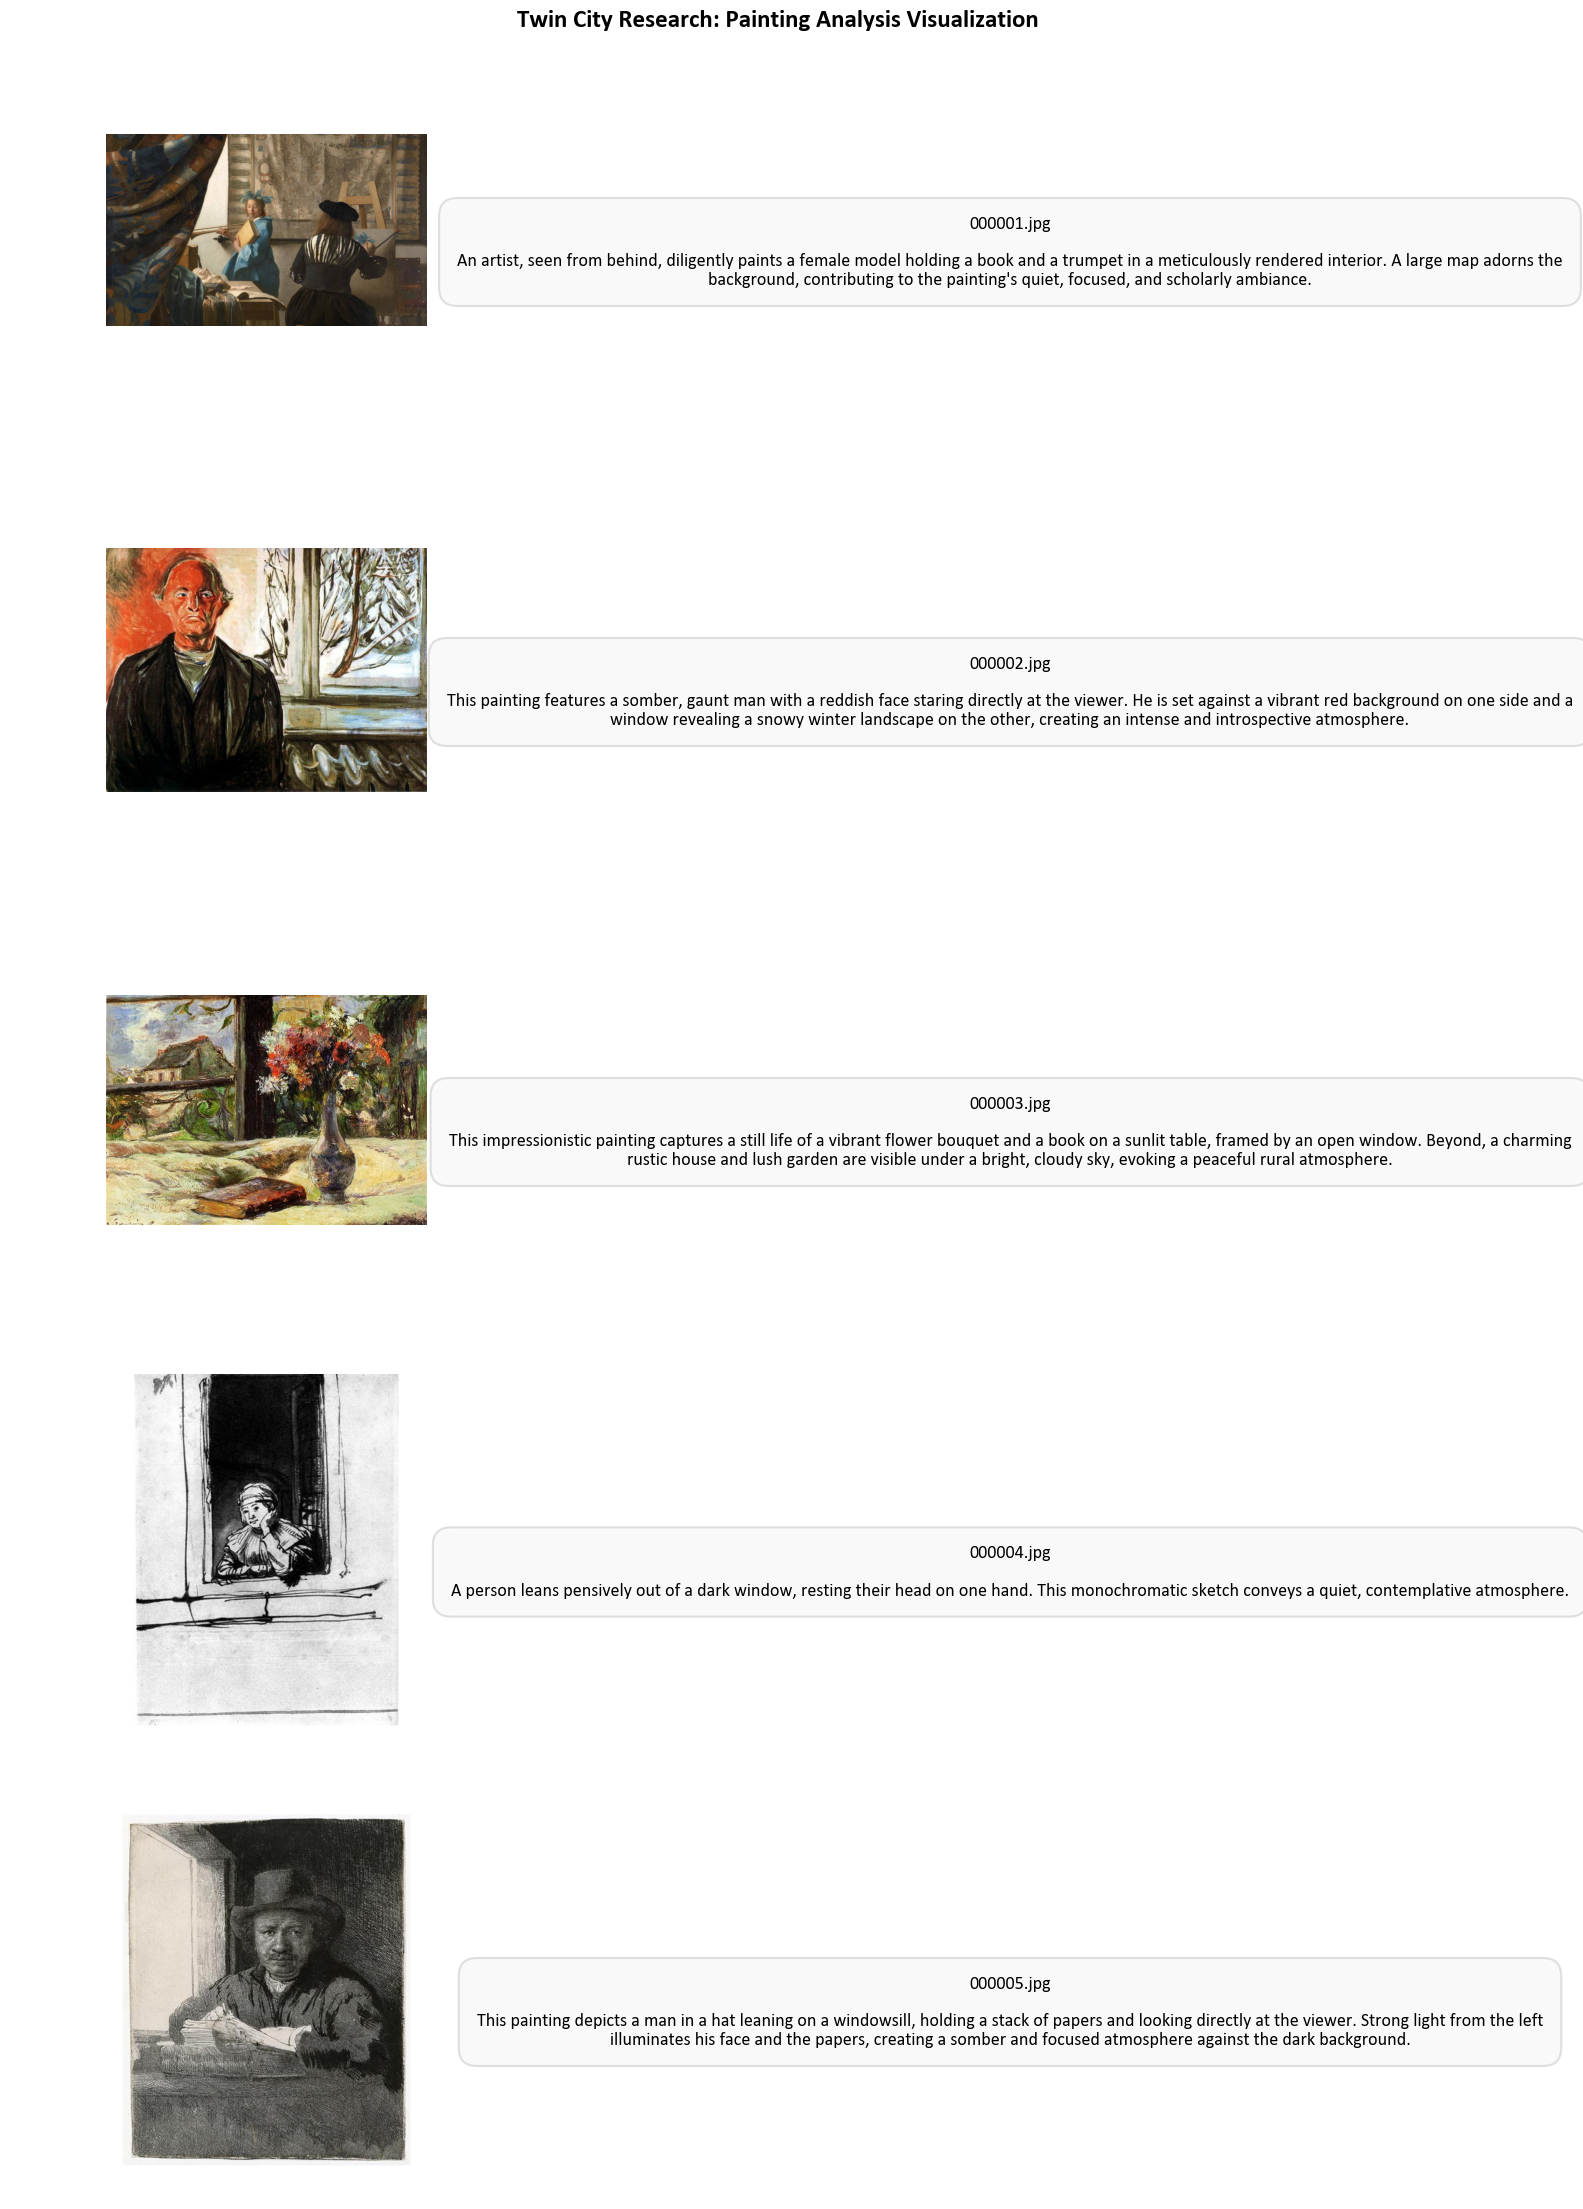


📋 前 5 张画作的完整信息：

【画作 1】
  📷 文件名: 000001.jpg
  📝 描述: An artist, seen from behind, diligently paints a female model holding a book and a trumpet in a meticulously rendered interior. A large map adorns the background, contributing to the painting's quiet, focused, and scholarly ambiance.
----------------------------------------------------------------------------------------------------

【画作 2】
  📷 文件名: 000002.jpg
  📝 描述: This painting features a somber, gaunt man with a reddish face staring directly at the viewer. He is set against a vibrant red background on one side and a window revealing a snowy winter landscape on the other, creating an intense and introspective atmosphere.
----------------------------------------------------------------------------------------------------

【画作 3】
  📷 文件名: 000003.jpg
  📝 描述: This impressionistic painting captures a still life of a vibrant flower bouquet and a book on a sunlit table, framed by an open window. Beyond, a charming rustic house and lush 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

# ===== Step 1: Load Data =====
csv_path = r"C:\Users\asus\Desktop\RC11 TERM2\all_descriptions.csv"
img_folder = r"C:\Users\asus\Desktop\RC11 TERM2\huazuo"

df = pd.read_csv(csv_path, encoding='utf-8-sig')
print(f"✅ Loaded {len(df)} description records\n")

# ===== Step 2: Create Vertical Visualization =====
# Select first 5 records
df_display = df.head(5)

# Set font to Calibri
plt.rcParams['font.family'] = 'Calibri'
plt.rcParams['font.size'] = 12

# Create figure: 5 rows x 1 column (vertical layout)
fig, axes = plt.subplots(5, 1, figsize=(16, 22))
fig.patch.set_facecolor('white')

for idx, (_, row) in enumerate(df_display.iterrows()):
    ax = axes[idx]
    filename = row['Image Number']
    description = row['Description']
    
    # Get image
    img_path = os.path.join(img_folder, filename)
    try:
        img = Image.open(img_path)
        
        ax.axis('off')
        
        # Calculate row position
        row_height = 1 / 5
        top = 1 - (idx) * row_height - 0.02
        bottom = top - row_height + 0.02
        
        # Left side image (centered)
        left_ax = fig.add_axes([0.08, bottom + 0.015, 0.2, row_height - 0.04])
        left_ax.imshow(img)
        left_ax.axis('off')
        
        # Right side description (centered)
        right_ax = fig.add_axes([0.32, bottom, 0.65, row_height - 0.03])
        right_ax.axis('off')
        
        # Add filename and description with larger font, centered alignment
        text_content = f"{filename}\n\n{description}"
        right_ax.text(0.5, 0.5, text_content,
                     transform=right_ax.transAxes,
                     fontsize=13,
                     family='Calibri',
                     verticalalignment='center',
                     horizontalalignment='center',
                     wrap=True,
                     bbox=dict(boxstyle='round,pad=1', 
                              facecolor='#f9f9f9', 
                              edgecolor='#ddd',
                              linewidth=1.5,
                              alpha=0.95))
        
    except Exception as e:
        ax.text(0.5, 0.5, f"❌ Load failed\n{filename}", 
                transform=ax.transAxes, 
                ha='center', 
                va='center',
                fontsize=12,
                family='Calibri',
                color='red')
        ax.axis('off')

# Overall title
fig.suptitle('Twin City Research: Painting Analysis Visualization', 
             fontsize=18, 
             fontweight='bold', 
             family='Calibri',
             y=0.995)

plt.subplots_adjust(top=0.98, bottom=0.02, left=0.02, right=0.98)
plt.savefig(r"C:\Users\asus\Desktop\RC11 TERM2\visualization_vertical_top5.png", dpi=150, bbox_inches='tight')
print("✅ Vertical visualization saved to: C:\\Users\\asus\\Desktop\\RC11 TERM2\\visualization_vertical_top5.png")
plt.show()

# ===== Step 3: Detailed Information Output =====
print("\n" + "="*100)
print("📋 Complete Information of Top 5 Paintings:")
print("="*100)

for idx, (_, row) in enumerate(df_display.iterrows(), 1):
    print(f"\n【Painting {idx}】")
    print(f"  📷 Filename: {row['Image Number']}")
    print(f"  📝 Description: {row['Description']}")
    print("-" * 100)

print("\n✨ Vertical visualization complete!")

## Section 3: Visualization & Results Display

This section creates a professional vertical layout visualization combining images with their AI-generated descriptions. The layout is designed for academic presentations and documentation.

### Output Format:
- **Left side**: Original painting image
- **Right side**: Filename and AI-generated description in a text box
- **Resolution**: 150 DPI for high-quality PDF export
- **Font**: Calibri for professional appearance